In [ ]:
import tensorflow as tf
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import os
import torch

In [ ]:
from tensorflow.keras.applications import InceptionV3
model = InceptionV3(weights='imagenet', include_top=True)
model.summary()

96112376/96112376 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "inception_v3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 149, 149,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 149, 149,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 149, 149,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 147, 147,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 147, 147,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 73, 73,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 73, 73,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 73, 73,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 73, 73,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 71, 71,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 71, 71,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 71, 71,    │          0 │ batch_normalizat

 Total params: 23,851,784 (90.99 MB)

 Trainable params: 23,817,352 (90.86 MB)

 Non-trainable params: 34,432 (134.50 KB)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Avoid OOM errors by setting GPU Memory Consumption Growth
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

In [ ]:
data = tf.keras.utils.image_dataset_from_directory(r'/content/drive/MyDrive/Images/Images')

Found 547 files belonging to 2 classes.


In [ ]:
data.class_names

['TCImages', 'TSImages']

In [ ]:
data_iterator = data.as_numpy_iterator()

In [ ]:
batch = data_iterator.next()

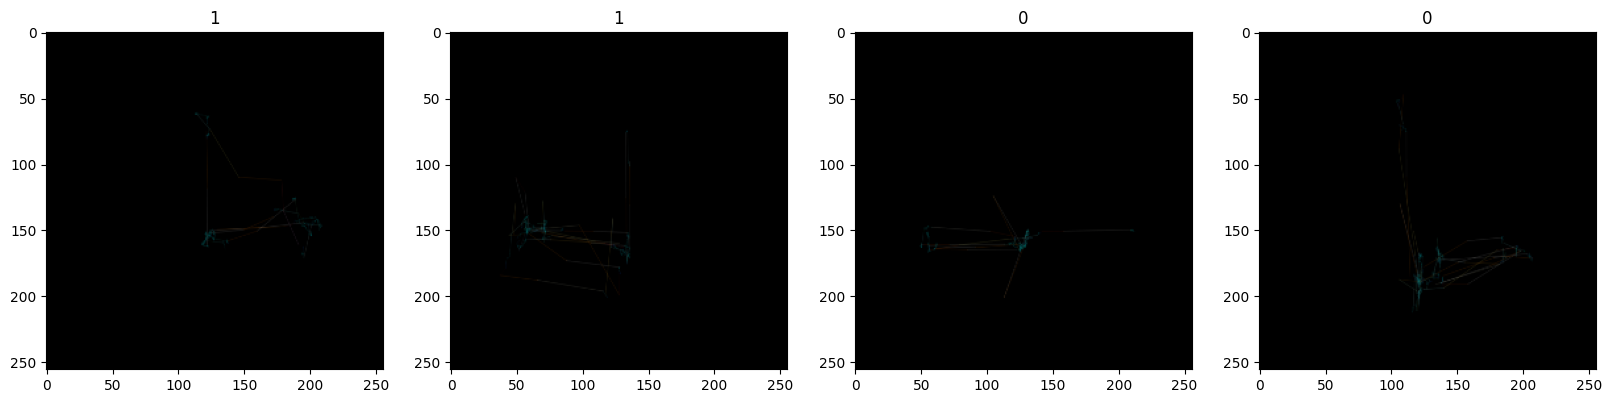

In [ ]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])

In [ ]:
batch[0].shape

(32, 256, 256, 3)

In [ ]:
batch[0].max()

np.float32(110.484375)

In [ ]:
data = data.map(lambda x,y: (x/255, y))

In [ ]:
scaled_iterator = data.as_numpy_iterator()

In [ ]:
batch = scaled_iterator.next()

In [ ]:
batch[0].max()

np.float32(0.5799632)

In [ ]:
batch[0].min()

np.float32(0.0)

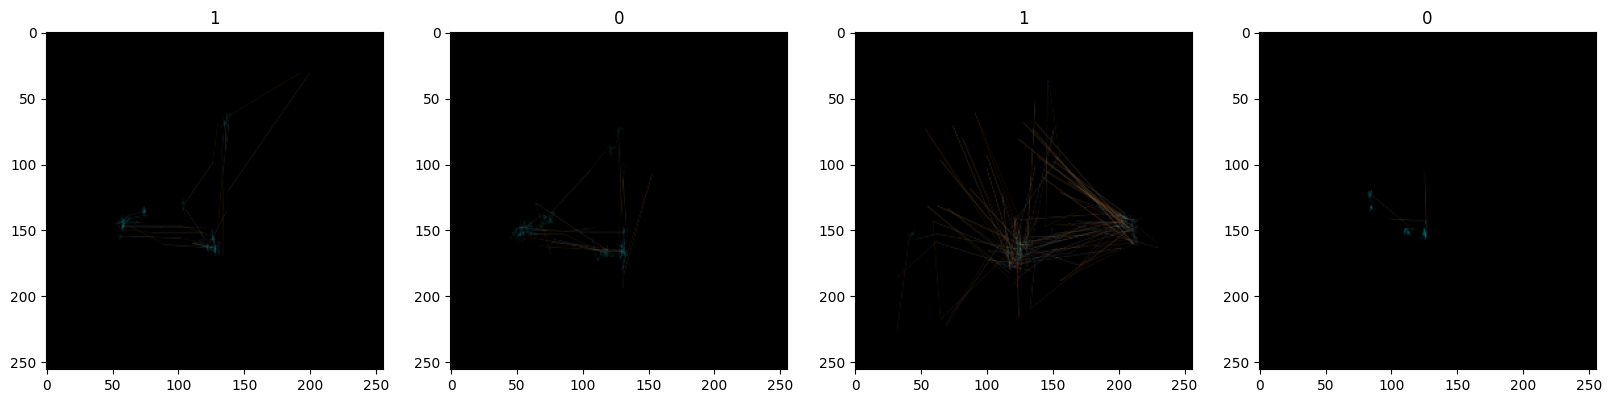

In [ ]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img)
    ax[idx].title.set_text(batch[1][idx])

In [ ]:
tf.keras.utils.image_dataset_from_directory('/content/drive/MyDrive/Images/Images')

Found 547 files belonging to 2 classes.


<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [ ]:
len(data)

18

In [ ]:
train_size = 12 #    ≈ 70%
val_size = 3    #    ≈ 20%
test_size = 2   #    ≈ 10%

In [ ]:
train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size + val_size).take(test_size)

In [ ]:
def augment_pre_fmmix1(images, labels):
    images = tf.image.random_flip_left_right(images)  # Lật ngang
    images = tf.image.random_brightness(images, max_delta=0.1)  # Thay đổi độ sáng
    images = tf.image.random_contrast(images, lower=0.8, upper=1.2)  # Tăng giảm độ tương phản -> sửa thành 0.9 & 1.1
    return images, labels

In [ ]:
# Giả lập đối tượng args
class Args:
    def __init__(self, alpha=0.2, mask_area_mode=1):
        self.alpha = alpha
        self.mask_area_mode = mask_area_mode

# Hàm fmmix1
def fmmix1(args, x: torch.Tensor, target: torch.Tensor):
    B, C, H, W = x.shape
    lam = args.alpha

    shuffle_idx = torch.randperm(B)
    x_shuffle = x[shuffle_idx]

    max_val_indices = torch.argmax(x_shuffle.view(B, C, -1), dim=2)
    max_indices_unraveled = torch.stack((max_val_indices // W, max_val_indices % W), dim=-1)

    if args.mask_area_mode in [0, 1]:
        lambdas = torch.sqrt(lam * torch.ones(B, 1, 1, 1, device=x.device))
        Wb = (lambdas * W).squeeze(-1)
        Hb = (lambdas * H).squeeze(-1)
    elif args.mask_area_mode in [2, 3]:
        Wb = torch.rand(B, 1, 1, device=x.device) * W
        if args.mask_area_mode == 2:
            lambdas = lam * torch.ones(B, 1, 1, device=x.device)
            Hb = (lambdas * W * H) / Wb
        else:
            lambdas = lam * torch.rand(B, 1, 1, device=x.device)
            max_Hb = (lambdas * W * H) / Wb
            Hb = torch.rand(B, 1, 1, device=x.device) * max_Hb
        Hb = torch.min(Hb, H * torch.ones_like(Hb))

    x_range = torch.arange(W, device=x.device)[None, :].expand(B, C, H, W)
    y_range = torch.arange(H, device=x.device)[:, None].expand(B, C, H, W)
    x_min = torch.clamp(max_indices_unraveled[..., 1][..., None, None] - Wb[..., None] // 2, 0, W)
    y_min = torch.clamp(max_indices_unraveled[..., 0][..., None, None] - Hb[..., None] // 2, 0, H)
    x_max = torch.clamp(x_min + Wb[..., None], 0, W)
    y_max = torch.clamp(y_min + Hb[..., None], 0, H)

    masks = (x_range >= x_min) & (x_range < x_max) & (y_range >= y_min) & (y_range < y_max)
    x = x * ~masks + x_shuffle * masks

    target_shuffled = target[shuffle_idx]
    p_src = torch.sum(masks, dim=[1,2,3])/(C*W*H)
    p_tar = 1 - p_src

    computation_loss_components = [2, [p_tar, p_src], [target, target_shuffled]]
    return x, computation_loss_components



# Hàm áp dụng fmmix1 cho dataset của TensorFlow
def apply_fmmix1_tf(images, labels):
    images = tf.cast(images, tf.float32)

    def fmmix1_wrapper(images_np, labels_np):
        images_torch = torch.from_numpy(images_np)
        labels_torch = torch.from_numpy(labels_np.astype(np.int64))  # Chuyển labels thành int64

        args = Args(alpha=0.2, mask_area_mode=1)
        images_aug, _ = fmmix1(args, images_torch, labels_torch)

        return images_aug.numpy(), labels_np.astype(np.int64)  # Đảm bảo numpy output là int64

    augmented_images, new_labels = tf.numpy_function(
        func=fmmix1_wrapper,
        inp=[images, labels],
        Tout=[tf.float32, tf.int64]  # Bắt buộc labels là tf.int64
    )

    # Giữ nguyên shape
    augmented_images.set_shape(images.shape)
    new_labels.set_shape(labels.shape)

    return augmented_images, new_labels


In [ ]:
pre_fmmix1_aug_train = train.map(lambda x, y: augment_pre_fmmix1(x, y))

In [ ]:
aug_train = pre_fmmix1_aug_train.map(lambda x, y: apply_fmmix1_tf(x, y))

In [ ]:
len(train), len(aug_train), len(val), len(test)

(12, 12, 3, 2)

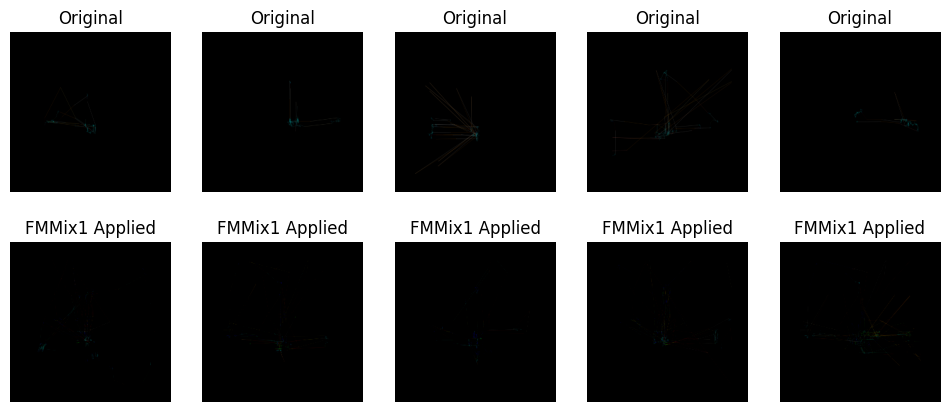

In [ ]:
import matplotlib.pyplot as plt

# Lấy một batch từ dataset gốc
for images, labels in train.take(1):
    break

# Lấy một batch sau khi áp dụng fmmix1
for aug_images, aug_labels in aug_train.take(1):
    break

# Chuyển về numpy để hiển thị
images_np = images.numpy()
aug_images_np = aug_images.numpy()

# Hiển thị ảnh trước và sau khi augment
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i in range(5):
    axes[0, i].imshow(images_np[i])  # Ảnh gốc
    axes[0, i].axis("off")
    axes[0, i].set_title("Original")

    axes[1, i].imshow(aug_images_np[i])  # Ảnh sau khi fmmix1
    axes[1, i].axis("off")
    axes[1, i].set_title("FMMix1 Applied")

plt.show()


In [ ]:
logdir='logs'

In [ ]:
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)

In [ ]:
import tensorflow as tf
import keras_tuner as kt
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

def build_model(hp):
    base_model = InceptionV3(include_top=False, input_shape=(256, 256, 3), weights='imagenet')

    # Unfreeze from specified layer
    unfreeze_from = hp.Choice('unfreeze_from', ['block5a_expand', 'block6a_expand', 'mixed7'])
    set_trainable = False
    for layer in base_model.layers:
        if unfreeze_from in layer.name:
            set_trainable = True
        layer.trainable = set_trainable

    inputs = tf.keras.Input(shape=(256, 256, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)

    # Dynamic CNN head: add 1–3 dense layers
    for i in range(hp.Int('num_dense_layers', 1, 3)):
        x = layers.Dense(
            units=hp.Int(f'units_{i}', min_value=64, max_value=512, step=64),
            activation=hp.Choice(f'activation_{i}', ['relu', 'tanh'])
        )(x)
        x = layers.Dropout(
            rate=hp.Float(f'dropout_{i}', min_value=0.2, max_value=0.5, step=0.1)
        )(x)

    outputs = layers.Dense(1, activation='sigmoid')(x)
    model = models.Model(inputs, outputs)

    model.compile(
        optimizer=Adam(hp.Choice('lr', [1e-3, 1e-4, 1e-5])),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=30,
    directory='hypertune_inception',
    project_name='fmmix1_dynamic')

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

tuner.search(
    aug_train,
    validation_data=val,
    epochs=75,
    callbacks=[early_stop, reduce_lr]
)

best_model = tuner.get_best_models(1)[0]
best_hp = tuner.get_best_hyperparameters(1)[0]

Trial 30 Complete [00h 01m 56s]
val_accuracy: 0.7604166865348816

Best val_accuracy So Far: 0.8645833134651184
Total elapsed time: 01h 38m 28s


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 110 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
import math
best_model = tuner.hypermodel.build(best_hp)

history = best_model.fit(
    aug_train,
    validation_data=val,
    epochs=100,
    steps_per_epoch = math.ceil(547 / 32),
    callbacks=[tensorboard_callback],
)

Epoch 1/100
12/18 ━━━━━━━━━━━━━━━━━━━━ 2s 379ms/step - accuracy: 0.6013 - loss: 0.6664

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


18/18 ━━━━━━━━━━━━━━━━━━━━ 47s 996ms/step - accuracy: 0.6083 - loss: 0.6576 - val_accuracy: 0.7396 - val_loss: 0.5468
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 16s 348ms/step - accuracy: 0.6346 - loss: 0.6218 - val_accuracy: 0.7292 - val_loss: 0.5415
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 369ms/step - accuracy: 0.6372 - loss: 0.6117 - val_accuracy: 0.6875 - val_loss: 0.5636
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 517ms/step - accuracy: 0.6649 - loss: 0.6156 - val_accuracy: 0.6771 - val_loss: 0.5912
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 339ms/step - accuracy: 0.7069 - loss: 0.5989 - val_accuracy: 0.8021 - val_loss: 0.4799
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 433ms/step - accuracy: 0.7325 - loss: 0.5644 - val_accuracy: 0.6979 - val_loss: 0.5531
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 12s 513ms/step - accuracy: 0.7804 - loss: 0.5115 - val_accuracy: 0.7083 - val_loss: 0.6549
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 357ms/step - accuracy: 0.7010 - loss: 0.5881 - val_accuracy: 0.

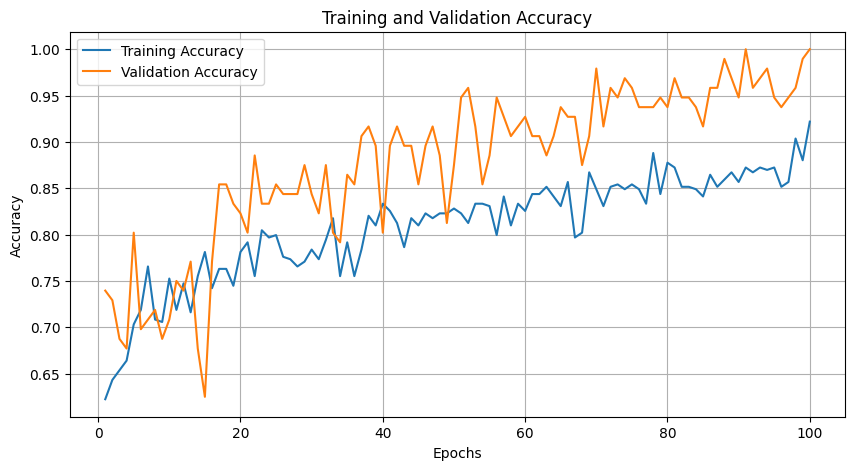

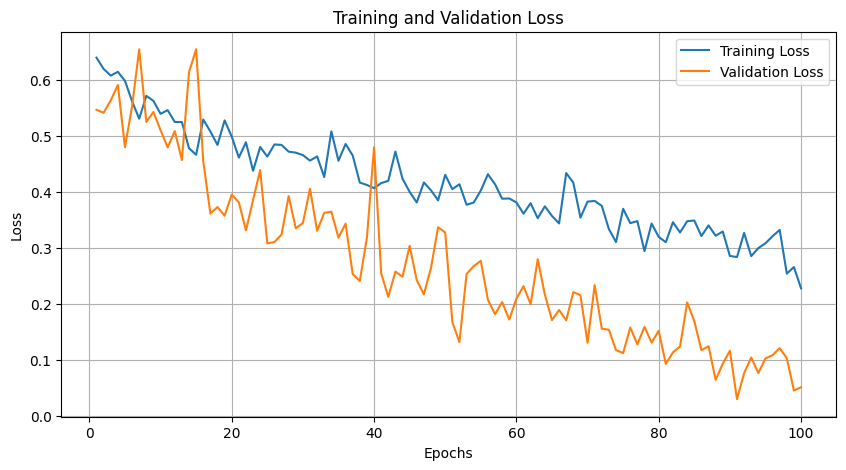

In [ ]:
# Giả sử bạn có lịch sử huấn luyện từ Keras
epochs = range(1, 101)
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# Accuracy
plt.figure(figsize=(10, 5))
plt.plot(epochs, train_acc, label='Training Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss
plt.figure(figsize=(10, 5))
plt.plot(epochs, train_loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# import pandas as pd
# df = pd.DataFrame({'Train Loss': history.history['loss'],'Validation Loss': history.history['val_loss'],'Train accuracy': history.history['accuracy'],'Validation accuracy': history.history['val_accuracy']})
# df.to_csv("augmented_CNN_history.csv")

In [ ]:
from tensorflow.keras.metrics import Precision, Recall, BinaryAccuracy
precision = Precision()
recall = Recall()
accuracy = BinaryAccuracy()

In [ ]:
y_all = []
yhat_all = []

In [ ]:
for batch in test.as_numpy_iterator():
    X, y = batch
    yhat = best_model.predict(X)

    y_all = y_all + list(y)
    yhat_all = yhat_all + list(yhat.round())

    precision.update_state(y, yhat)
    recall.update_state(y, yhat)
    accuracy.update_state(y, yhat)

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step


In [ ]:
y_all = np.array(y_all)

In [ ]:
yhat_all = np.array(yhat_all)

In [ ]:
y_all.shape, yhat_all.shape

((64,), (64, 1))

In [ ]:
yhat_all = yhat_all.reshape(-1)

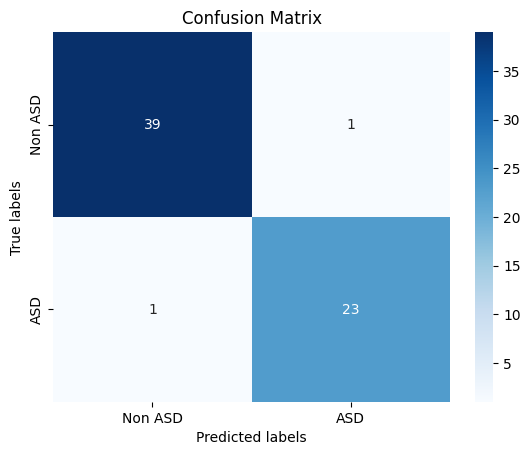

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Reshape 1D arrays to 2D arrays
y_all = np.array(y_all).reshape(-1, 1)
yhat_all = np.array(yhat_all).reshape(-1, 1)

conf_mat = confusion_matrix(y_all, yhat_all)

ax = plt.subplot()
sns.heatmap(conf_mat, annot=True, fmt='g', ax=ax, cmap='Blues')

# labels, title, and ticks
ax.set_xlabel('Predicted labels')
ax.set_ylabel('True labels')
ax.set_title('Confusion Matrix')
ax.xaxis.set_ticklabels(['Non ASD', 'ASD'])
ax.yaxis.set_ticklabels(['Non ASD', 'ASD'])

plt.show()

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
print(classification_report(y_all, yhat_all))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97        40
           1       0.96      0.96      0.96        24

    accuracy                           0.97        64
   macro avg       0.97      0.97      0.97        64
weighted avg       0.97      0.97      0.97        64



In [ ]:
# model.save(os.path.join('models','hyperparameter_tuning.h5'))